## Block 1. 환경설정

In [1]:
import os
import sys
import simpy
import random
import numpy as np
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from tqdm import tqdm
import time
from itertools import product
import json

# 시각화 한글 폰트 설정
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = ['Noto Sans KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 환경변수 로드
load_dotenv(override=True)

# 프로젝트 경로 설정
PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 환경 설정
os.environ["DOWN_ACTIVE"] = "True"
os.environ["PM_ACTIVE"] = "True"

# 데이터 경로
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data/large_data')

# ============================================================
# === SIMULATION PARAMETERS ===
# ============================================================
BASE_SEED = 42
N_REPLICATIONS = 10  # 시뮬레이션 반복 횟수 (조정 가능)

# Dispatching rules for comparison
JOB_RULES = ["MIN_QTIME", "FIFO", "SPT"]  # 비교할 job dispatching rules
MACHINE_RULE = "SPTSSU"

# ============================================================
# === PM RULE CONFIGURATION ===
# ============================================================
# Compare different PM rules: ["THRESHOLD", "MTTF"]
PM_RULES_TO_COMPARE = ["THRESHOLD", "MTTF"]

# THRESHOLD rule parameter
PM_THRESHOLD = 0.1  # Cumulative failure probability threshold

# MTTF rule parameters
GROUP_RISK_ASSIGNMENT = {
    "G1": "medium",
    "G2": "high",
    "G3": "low",
    "G4": "high",
    "G5": "medium",
}

RISK_COEFFICIENTS = {
    "high": 0.3,
    "medium": 0.5,
    "low": 0.7,
}

# ============================================================
# === ANALYSIS PARAMETERS ===
# ============================================================
QTIME_SENSITIVE_THRESHOLD = 120  # Q-time 민감도 분석 기준 (분 단위)
QTIME_WEIGHT = 1.0  # Total score 계산 시 Q-time violation 가중치

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_RULES_TO_COMPARE: {PM_RULES_TO_COMPARE}")
print(f"N_REPLICATIONS: {N_REPLICATIONS}")
print(f"JOB_RULES: {JOB_RULES}")
print(f"MACHINE_RULE: {MACHINE_RULE}")
print(f"=== Configuration Ready ==="")


PROJECT_ROOT: /Users/miles/Documents/전종설/workspace/simulation_teamwork/simulation_teamwork
BASE_DATA_PATH: data/large_data
PM_RULE: MTTF
N_REPLICATIONS: 30
JOB_RULES: ['MIN_QTIME']
MACHINE_RULE: SPTSSU


## Block 2. 모듈 Import

In [2]:
from math import gamma, log
from utils import DataLoader, EventLogger
from utils.pm_policy import (
    calculate_weibull_mttf,
    weibull_time_at_failure_prob,
    build_mttf_pm_policy,
    apply_mttf_pm_rule,
    get_pm_interval_by_rule,  # NEW: Unified PM rule interface
)
from simulation import Scheduler

print("✓ All modules imported successfully!")

All modules imported successfully!


## Block 3. 데이터 로드

In [3]:
# DataLoader를 이용해 데이터 로드
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()

# 각 DataFrame 추출
jobs_df = data['jobs']
machines_df = data['machines']
operations_df = data['operations']
op_machine_df = data['operation_machine_map']
setup_times_df = data['setup_times']
machine_failure_df = data['machine_failure']

print("=== 데이터 로드 완료 ===")
print(f"jobs: {jobs_df.shape}")
print(f"machines: {machines_df.shape}")
print(f"operations: {operations_df.shape}")
print(f"operation_machine_map: {op_machine_df.shape}")
print(f"setup_times: {setup_times_df.shape}")
print(f"machine_failure: {machine_failure_df.shape}")

# Machine group 확인
print(f"\nAvailable Machine Groups: {machines_df['machine_group'].unique()}")

# Machines과 machine_failure 데이터 매칭 확인
print(f"\n=== 데이터 매칭 확인 ===")
merged_check = machines_df.merge(machine_failure_df, on='machine_id', how='left')
print(f"Merged data (machines + failure): {merged_check.shape}")
print(f"Any unmatched machines: {merged_check['shape parameter'].isna().sum()}")

display(machines_df.head())
display(machine_failure_df.head())

=== 데이터 로드 완료 ===
jobs: (60, 5)
machines: (60, 2)
operations: (840, 5)
operation_machine_map: (16440, 3)
setup_times: (20, 4)
machine_failure: (60, 5)

Available Machine Groups: ['G1' 'G2' 'G3' 'G4' 'G5']

=== 데이터 매칭 확인 ===
Merged data (machines + failure): (60, 6)
Any unmatched machines: 0


,machine_id,machine_group
0,M1,G1
1,M2,G1
2,M3,G1
3,M4,G1
4,M5,G1


,machine_id,shape parameter,scale parameter,repair_time,pm_duration
0,M1,3.0,11000,220,80
1,M2,3.0,11000,220,80
2,M3,3.0,11000,220,80
3,M4,3.0,11000,220,80
4,M5,3.0,11000,220,80


## Block 4. Machine Group별 특성 요약

In [4]:
# Machine group별 Weibull parameter summary
op_machine_df_with_group = op_machine_df.merge(
    machines_df[['machine_id', 'machine_group']],
    on='machine_id',
    how='left'
)

group_summary = machines_df.merge(machine_failure_df, on='machine_id').groupby('machine_group').agg({
    'machine_id': 'count',
    'shape parameter': 'mean',
    'scale parameter': 'mean',
    'repair_time': 'mean',
    'pm_duration': 'mean',
}).reset_index()

group_summary.columns = ['machine_group', 'machine_count', 'avg_shape_parameter', 
                         'avg_scale_parameter', 'avg_repair_time', 'avg_pm_duration']

# Operation count per machine group
op_counts = op_machine_df_with_group.groupby('machine_group')['op_id'].nunique().reset_index()
op_counts.columns = ['machine_group', 'total_available_operations']

# Processing time stats per machine group
pt_stats = op_machine_df_with_group.groupby('machine_group').agg({
    'process_time': ['mean', 'sum']
}).reset_index()
pt_stats.columns = ['machine_group', 'avg_processing_time', 'total_processing_time']

# Combine all group summaries
group_info = group_summary.merge(op_counts, on='machine_group').merge(pt_stats, on='machine_group')

print("=== Machine Group 특성 요약 ===")
display(group_info)

=== Machine Group 특성 요약 ===


,machine_group,machine_count,avg_shape_parameter,avg_scale_parameter,avg_repair_time,avg_pm_duration,total_available_operations,avg_processing_time,total_processing_time
0,G1,30,3.0,11000.0,220.0,80.0,390,479.824868,5613950.95
1,G2,4,2.8,11000.0,600.0,200.0,90,173.354861,62407.75
2,G3,16,2.5,11000.0,150.0,50.0,210,421.319714,1415634.24
3,G4,8,2.2,11000.0,700.0,200.0,120,350.114125,336109.56
4,G5,2,3.3,11000.0,200.0,70.0,30,239.786500,14387.19


## Block 5. Weibull 분포 구조 및 MTTF 파악

In [5]:
# Machine별 MTTF 계산
machine_weibull = machines_df.merge(machine_failure_df, on='machine_id').copy()

# MTTF 계산
machine_weibull['mttf'] = machine_weibull.apply(
    lambda row: calculate_weibull_mttf(
        row['shape parameter'],
        row['scale parameter']
    ),
    axis=1
)

# 고장확률 p=0.1, 0.3, 0.5, 0.7에서의 시간 계산
for prob in [0.1, 0.3, 0.5, 0.7]:
    machine_weibull[f't_p{int(prob*100)}'] = machine_weibull.apply(
        lambda row: weibull_time_at_failure_prob(
            row['shape parameter'],
            row['scale parameter'],
            prob
        ),
        axis=1
    )

# Machine 레벨 표시
machine_display = machine_weibull[[
    'machine_id', 'machine_group', 'shape parameter', 'scale parameter',
    'mttf', 'repair_time', 'pm_duration', 't_p10', 't_p30', 't_p50', 't_p70'
]].copy()

print("=== Machine별 Weibull Parameter 및 MTTF ===")
display(machine_display)

# Group 레벨 MTTF 요약
group_mttf = machine_weibull.groupby('machine_group').agg({
    'shape parameter': 'mean',
    'scale parameter': 'mean',
    'mttf': 'mean',
    'repair_time': 'mean',
    'pm_duration': 'mean',
}).reset_index()

group_mttf.columns = ['machine_group', 'avg_shape_parameter', 'avg_scale_parameter',
                      'avg_mttf', 'avg_repair_time', 'avg_pm_duration']

print("\n=== Machine Group별 MTTF 요약 ===")
display(group_mttf)

=== Machine별 Weibull Parameter 및 MTTF ===


,machine_id,machine_group,shape parameter,scale parameter,mttf,repair_time,pm_duration,t_p10,t_p30,t_p50,t_p70
0,M1,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
1,M2,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
2,M3,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
3,M4,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
4,M5,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
5,M6,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
6,M7,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
7,M8,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
8,M9,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796
9,M10,G1,3.0,11000,9822.774627,220,80,5195.395904,7800.998943,9734.967490,11702.129796



=== Machine Group별 MTTF 요약 ===


,machine_group,avg_shape_parameter,avg_scale_parameter,avg_mttf,avg_repair_time,avg_pm_duration
0,G1,3.0,11000.0,9822.774627,220.0,80.0
1,G2,2.8,11000.0,9794.960489,600.0,200.0
2,G3,2.5,11000.0,9759.901993,150.0,50.0
3,G4,2.2,11000.0,9741.872365,700.0,200.0
4,G5,3.3,11000.0,9867.168826,200.0,70.0


## Block 6. Machine Group별 PM Interval 설정

**Note:** 현재는 group별 risk type을 수동으로 지정하지만, 추후 machine count, repair time, PM duration, q-time sensitive ratio, workload 등을 이용해 risk type 또는 coefficient를 자동 산정하도록 확장할 수 있다.

In [6]:
# ============================================================
# === PM INTERVAL 계산 ===
# ============================================================
# PM 규칙별로 PM interval 계산
pm_policies = {}  # {pm_rule: {machine_id: pm_interval}}
pm_policy_details = {}  # {pm_rule: (machine_policy_df, group_policy_df)}

print("\n" + "="*60)
print("PM INTERVAL 계산")
print("="*60)

for pm_rule in PM_RULES_TO_COMPARE:
    print(f"\n### {pm_rule} Rule ###")
    
    if pm_rule.upper() == "THRESHOLD":
        pm_interval_dict, machine_policy, group_policy = get_pm_interval_by_rule(
            pm_rule="THRESHOLD",
            machines_df=machines_df,
            machine_failure_df=machine_failure_df,
            threshold_value=PM_THRESHOLD,
        )
        print(f"Threshold: {PM_THRESHOLD}")
        
    elif pm_rule.upper() == "MTTF":
        pm_interval_dict, machine_policy, group_policy = get_pm_interval_by_rule(
            pm_rule="MTTF",
            machines_df=machines_df,
            machine_failure_df=machine_failure_df,
            group_risk_assignment=GROUP_RISK_ASSIGNMENT,
            risk_coefficients=RISK_COEFFICIENTS,
        )
        print(f"Risk Assignment: {GROUP_RISK_ASSIGNMENT}")
        print(f"Coefficients: {RISK_COEFFICIENTS}")
    
    pm_policies[pm_rule] = pm_interval_dict
    pm_policy_details[pm_rule] = (machine_policy, group_policy)
    
    # Show group-level summary
    print(f"\nGroup-level PM Policy Summary:")
    print(group_policy.to_string())
    print(f"\nAverage PM intervals per group:")
    if 'avg_pm_interval' in group_policy.columns:
        print(group_policy[['machine_group', 'machine_count', 'avg_pm_interval']].to_string())
    
    # Show first 5 machines
    print(f"\nMachine-level PM intervals (first 5):")
    sample_machines = list(pm_interval_dict.items())[:5]
    for machine_id, interval in sample_machines:
        print(f"  {machine_id}: {interval:.2f}")

=== Group-level PM Policy ===


,machine_group,machine_count,avg_shape_parameter,avg_scale_parameter,avg_mttf,avg_repair_time,avg_pm_duration,risk_type,pm_coefficient,avg_pm_interval
0,G1,30,3.0,11000.0,9822.774627,220.0,80.0,medium,0.5,4911.387314
1,G2,4,2.8,11000.0,9794.960489,600.0,200.0,high,0.4,3917.984196
2,G3,16,2.5,11000.0,9759.901993,150.0,50.0,low,0.6,5855.941196
3,G4,8,2.2,11000.0,9741.872365,700.0,200.0,high,0.4,3896.748946
4,G5,2,3.3,11000.0,9867.168826,200.0,70.0,medium,0.5,4933.584413



=== Machine-level PM Policy ===


,machine_id,machine_group,shape parameter,scale parameter,mttf,risk_type,pm_coefficient,pm_interval,repair_time,pm_duration
0,M1,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
1,M2,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
2,M3,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
3,M4,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
4,M5,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
5,M6,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
6,M7,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
7,M8,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
8,M9,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80
9,M10,G1,3.0,11000,9822.774627,medium,0.5,4911.387314,220,80



=== PM Interval Dictionary (첫 5개) ===
M1: 4911.39
M10: 4911.39
M11: 4911.39
M12: 4911.39
M13: 4911.39
... (총 60개 machine)

Total machines in pm_interval_dict: 60
Total machines in machines.csv: 60


## Block 7. 설정된 PM Interval대로 Rule별 반복 Simulation 수행

In [7]:
def run_pm_simulation(job_rule, machine_rule, pm_rule, pm_interval_dict=None, pm_threshold=None, seed=None):
    """
    Run simulation with specified PM rule
    
    Args:
        job_rule: Job dispatching rule
        machine_rule: Machine dispatching rule  
        pm_rule: PM rule ("THRESHOLD" or "MTTF")
        pm_interval_dict: PM intervals for each machine (for MTTF rule)
        pm_threshold: PM threshold (for THRESHOLD rule)
        seed: Random seed
    
    Returns:
        dict: Simulation metrics
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    env = simpy.Environment()
    event_logger = EventLogger()
    
    scheduler = Scheduler(
        env=env,
        event_logger=event_logger,
        jobs=jobs_df.to_dict('records'),
        machines=machines_df.to_dict('records'),
        operations=operations_df.to_dict('records'),
        op_machine_map=op_machine_df.to_dict('records'),
        setup_times=setup_times_df.to_dict('records'),
        machine_failure_info=machine_failure_df.to_dict('records'),
        job_rule=job_rule,
        machine_rule=machine_rule,
        pm_duration_dict=None,
        repair_time_dict=None,
    )
    
    # Set PM parameters based on rule
    if pm_rule.upper() == "MTTF" and pm_interval_dict is not None:
        scheduler.pm_interval_dict = pm_interval_dict
        scheduler.pm_threshold = None
    elif pm_rule.upper() == "THRESHOLD" and pm_threshold is not None:
        scheduler.pm_threshold = pm_threshold
        scheduler.pm_interval_dict = None
    
    env.run()
    
    # Calculate metrics
    events = event_logger.events
    makespan = max([e['timestamp'] for e in events if e['event_type'] == 'job_completed'], default=0)
    
    # Q-time violations
    qtime_violations = len([e for e in events if 'qtime_violated' in e.get('details', '')])
    
    # PM and repair statistics
    pm_count = len([e for e in events if e['event_type'] == 'pm_start'])
    repair_count = len([e for e in events if e['event_type'] == 'failure_detected'])
    total_pm_time = sum([e.get('duration', 0) for e in events if e['event_type'] == 'pm_start'])
    total_repair_time = sum([e.get('duration', 0) for e in events if e['event_type'] == 'repair_start'])
    
    return {
        'job_rule': job_rule,
        'machine_rule': machine_rule,
        'pm_rule': pm_rule,
        'makespan': makespan,
        'qtime_violation': qtime_violations,
        'pm_count': pm_count,
        'repair_count': repair_count,
        'total_pm_time': total_pm_time,
        'total_repair_time': total_repair_time,
    }

run_pm_simulation 함수 정의 완료


In [8]:
# ============================================================
# === 반복 시뮬레이션 실행 (PM Rule별 비교) ===
# ============================================================
all_results = []
base_seed = BASE_SEED

# Calculate total runs
total_runs = len(PM_RULES_TO_COMPARE) * len(JOB_RULES) * N_REPLICATIONS

print(f"\n시뮬레이션 시작")
print(f"  PM Rules: {PM_RULES_TO_COMPARE}")
print(f"  Job Rules: {JOB_RULES}")
print(f"  Replications: {N_REPLICATIONS}")
print(f"  Total Runs: {total_runs}\n")

with tqdm(total=total_runs, desc="Simulations", unit="run") as pbar:
    for pm_rule in PM_RULES_TO_COMPARE:
        print(f"\n### PM Rule: {pm_rule} ###")
        
        for job_rule in JOB_RULES:
            for rep_idx in range(N_REPLICATIONS):
                seed = base_seed + rep_idx
                
                # Select PM parameters
                if pm_rule.upper() == "MTTF":
                    pm_interval_dict = pm_policies[pm_rule]
                    result = run_pm_simulation(
                        job_rule=job_rule,
                        machine_rule=MACHINE_RULE,
                        pm_rule=pm_rule,
                        pm_interval_dict=pm_interval_dict,
                        seed=seed
                    )
                else:  # THRESHOLD
                    result = run_pm_simulation(
                        job_rule=job_rule,
                        machine_rule=MACHINE_RULE,
                        pm_rule=pm_rule,
                        pm_threshold=PM_THRESHOLD,
                        seed=seed
                    )
                
                all_results.append(result)
                pbar.update(1)

pm_compare_results = pd.DataFrame(all_results)
print(f"\n✓ 시뮬레이션 완료: {len(pm_compare_results)} runs")
print(f"\nResult columns: {pm_compare_results.columns.tolist()}")
print(f"\nFirst 5 results:")
print(pm_compare_results.head())

시뮬레이션 시작: 30회
JOB_RULES: ['MIN_QTIME']
MACHINE_RULE: SPTSSU
PM_RULE: MTTF
N_REPLICATIONS: 30


시뮬레이션 진행: 100%|██████████| 30/30 [00:36<00:00,  1.22s/run]


시뮬레이션 완료! 총 30회 실행

=== 시뮬레이션 결과 (처음 5행) ===


,job_rule,machine_rule,pm_rule,pm_policy,seed,makespan,qtime_violation,pm_count,repair_count,total_pm_time,total_repair_time
0,MIN_QTIME,SPTSSU,MTTF,MTTF_GROUP_RISK,42,9615.710000,477.401054,66,11,7240.0,3860.0
1,MIN_QTIME,SPTSSU,MTTF,MTTF_GROUP_RISK,43,9605.520000,655.072206,66,14,7540.0,3530.0
2,MIN_QTIME,SPTSSU,MTTF,MTTF_GROUP_RISK,44,9497.600000,245.061054,68,8,7880.0,1620.0
3,MIN_QTIME,SPTSSU,MTTF,MTTF_GROUP_RISK,45,9628.210000,271.217290,66,9,7660.0,2110.0
4,MIN_QTIME,SPTSSU,MTTF,MTTF_GROUP_RISK,46,9490.418824,269.410000,68,10,7730.0,2470.0



결과 DataFrame shape: (30, 11)


## Block 8. 시뮬레이션 결과 집계 및 Summary

In [9]:
# ============================================================
# === 시뮬레이션 결과 집계 및 분석 ===
# ============================================================

# Rule 조합별 (PM_RULE + JOB_RULE) 평균 및 표준편차 계산
print("\n=== Results by PM Rule and Job Rule ===\n")

summary_stats = []
for pm_rule in PM_RULES_TO_COMPARE:
    subset = pm_compare_results[pm_compare_results['pm_rule'] == pm_rule]
    
    group_stats = subset.groupby('job_rule').agg({
        'makespan': ['mean', 'std', 'min', 'max'],
        'qtime_violation': ['mean', 'std'],
        'pm_count': 'mean',
        'repair_count': 'mean',
        'total_pm_time': 'mean',
        'total_repair_time': 'mean',
    }).round(2)
    
    print(f"\n### PM Rule: {pm_rule} ###")
    print(group_stats)
    
    # Flatten columns
    group_stats_flat = subset.groupby('job_rule').agg({
        'makespan': 'mean',
        'qtime_violation': 'mean',
        'pm_count': 'mean',
    }).reset_index()
    group_stats_flat['pm_rule'] = pm_rule
    summary_stats.append(group_stats_flat)

summary_all = pd.concat(summary_stats, ignore_index=True)

# PM rule별 전체 평균
print(f"\n=== Overall Statistics by PM Rule ===\n")
pm_rule_summary = pm_compare_results.groupby('pm_rule').agg({
    'makespan': ['mean', 'std'],
    'qtime_violation': ['mean', 'std'],
    'pm_count': 'mean',
    'repair_count': 'mean',
    'total_pm_time': 'mean',
    'total_repair_time': 'mean',
}).round(2)
print(pm_rule_summary)
print()

=== Job Rule별 성능 요약 ===


,job_rule,avg_makespan,std_makespan,avg_qtime_violation,std_qtime_violation,avg_pm_count,avg_repair_count,avg_total_pm_time,avg_total_repair_time,avg_total_score
0,MIN_QTIME,9627.618274,116.823942,428.981807,373.207198,67.1,11.033333,7603.068492,2906.628945,10056.600081



=== 전체 통계 ===
평균 Makespan: 9627.62 (std: 116.82)
평균 Q-time Violation: 428.98
평균 PM Count: 67.10
평균 Repair Count: 11.03
평균 Total PM Time: 7603.07
평균 Total Repair Time: 2906.63


## Block 9. Makespan 분포 비교

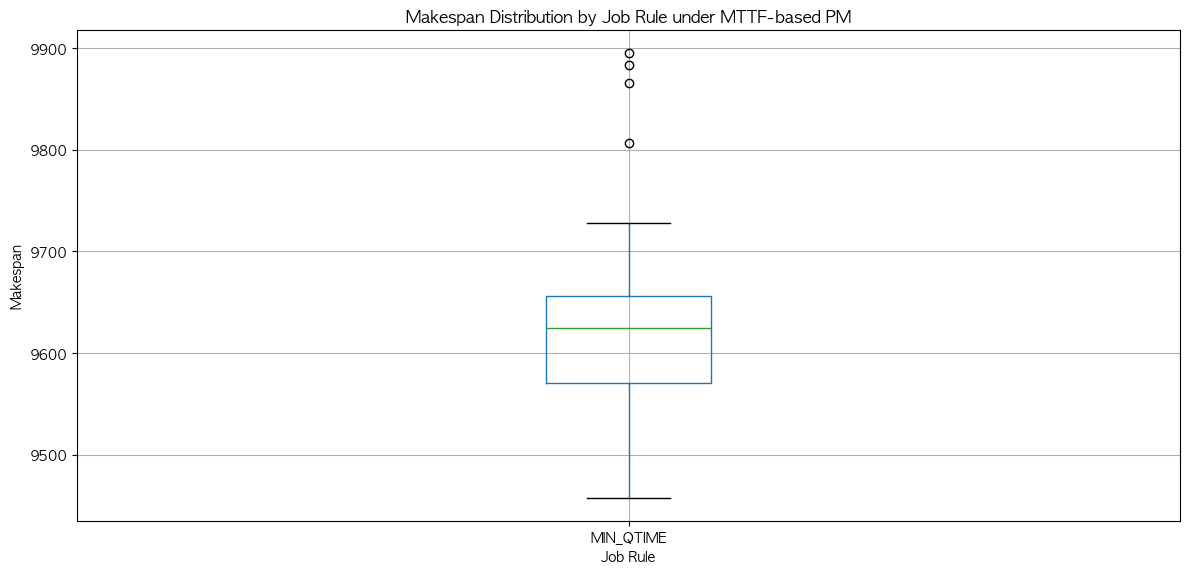

In [10]:
# ============================================================
# === Makespan 분포 비교 ===
# ============================================================

# 1. PM Rule별 Makespan 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, pm_rule in enumerate(PM_RULES_TO_COMPARE):
    subset = pm_compare_results[pm_compare_results['pm_rule'] == pm_rule]
    subset.boxplot(column='makespan', by='job_rule', ax=axes[idx])
    axes[idx].set_title(f'Makespan Distribution (PM Rule: {pm_rule})')
    axes[idx].set_xlabel('Job Rule')
    axes[idx].set_ylabel('Makespan (time units)')
    axes[idx].get_figure().suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# 2. PM Rule & Job Rule 조합별 Makespan 비교
fig, ax = plt.subplots(figsize=(14, 6))
pm_compare_results.boxplot(column='makespan', by=['pm_rule', 'job_rule'], ax=ax)
plt.suptitle('')
ax.set_title('Makespan Distribution by PM Rule and Job Rule')
ax.set_xlabel('(PM Rule, Job Rule)')
ax.set_ylabel('Makespan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Block 10. Q-time Violation 분포 비교

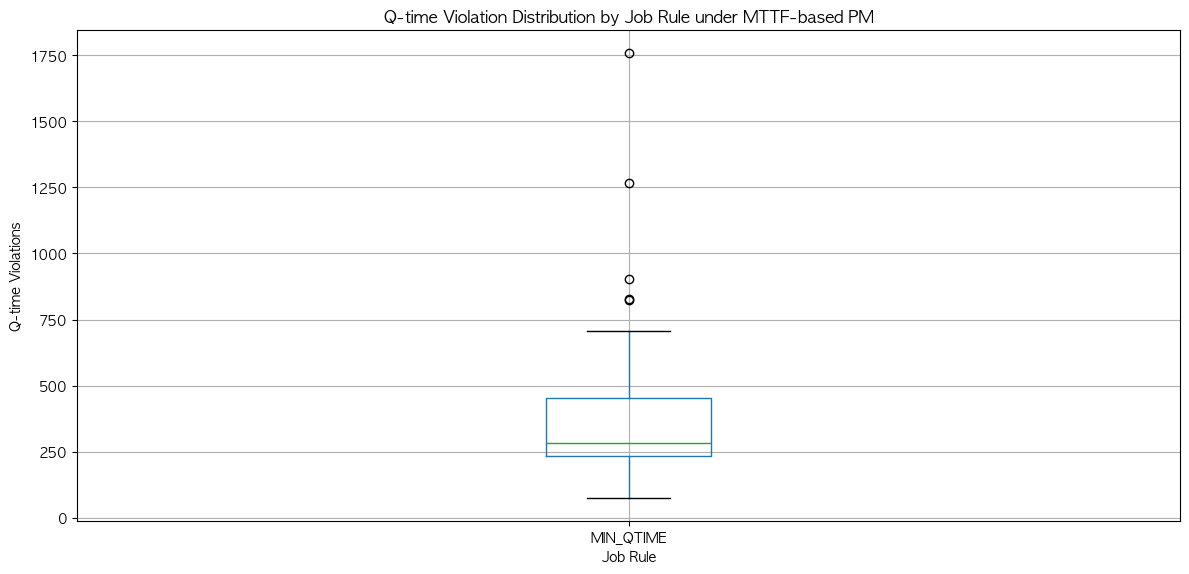

In [11]:
# ============================================================
# === Q-time Violation 분포 비교 ===
# ============================================================

# 1. PM Rule별 Q-time Violation 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, pm_rule in enumerate(PM_RULES_TO_COMPARE):
    subset = pm_compare_results[pm_compare_results['pm_rule'] == pm_rule]
    subset.boxplot(column='qtime_violation', by='job_rule', ax=axes[idx])
    axes[idx].set_title(f'Q-time Violation Distribution (PM Rule: {pm_rule})')
    axes[idx].set_xlabel('Job Rule')
    axes[idx].set_ylabel('Q-time Violations (count)')
    axes[idx].get_figure().suptitle('')

plt.tight_layout()
plt.show()

# 2. PM Rule & Job Rule 조합별 비교
fig, ax = plt.subplots(figsize=(14, 6))
pm_compare_results.boxplot(column='qtime_violation', by=['pm_rule', 'job_rule'], ax=ax)
plt.suptitle('')
ax.set_title('Q-time Violation Distribution by PM Rule and Job Rule')
ax.set_xlabel('(PM Rule, Job Rule)')
ax.set_ylabel('Q-time Violations (count)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Block 11. PM & Repair 메트릭 비교

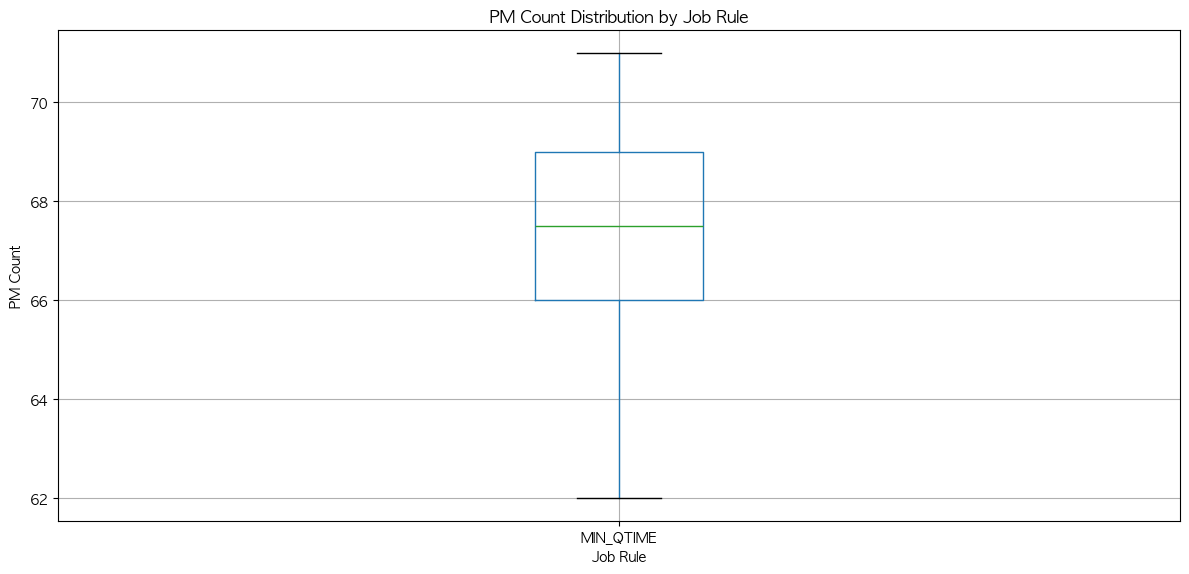

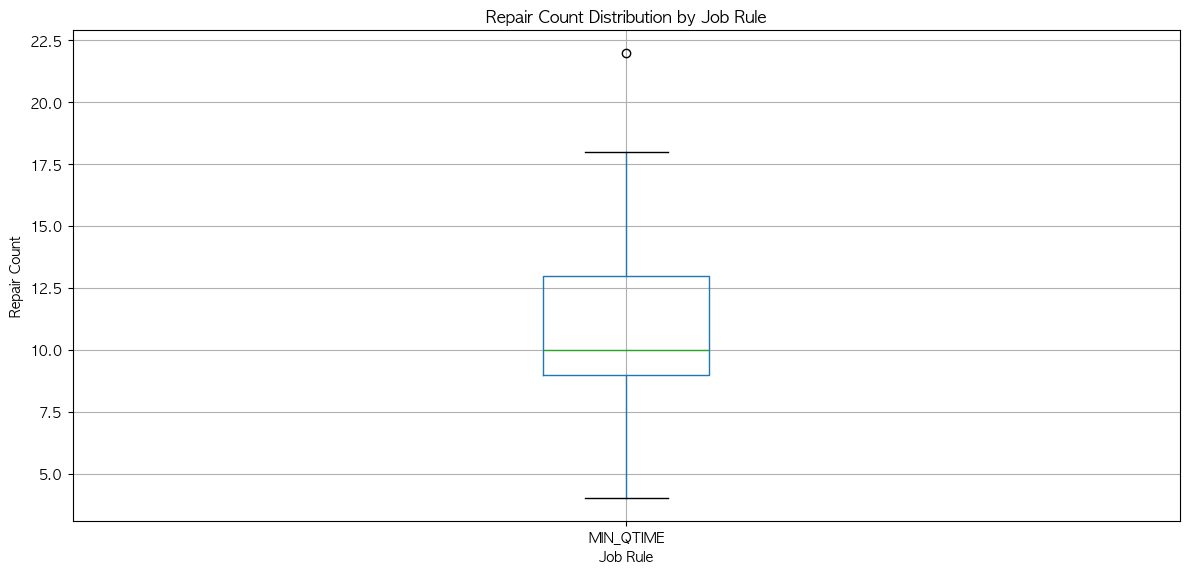

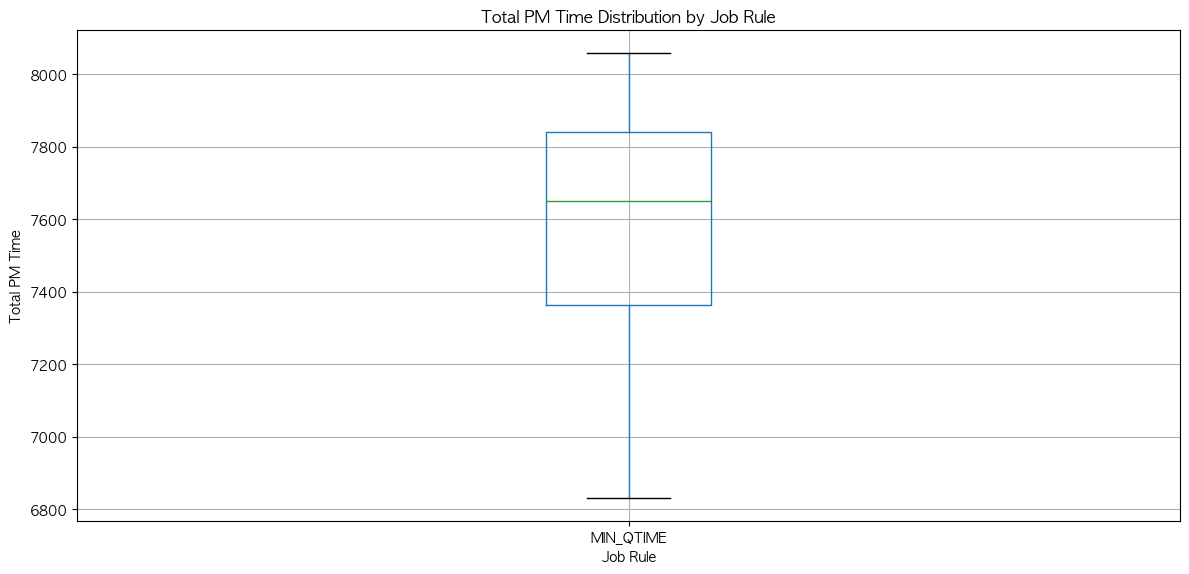

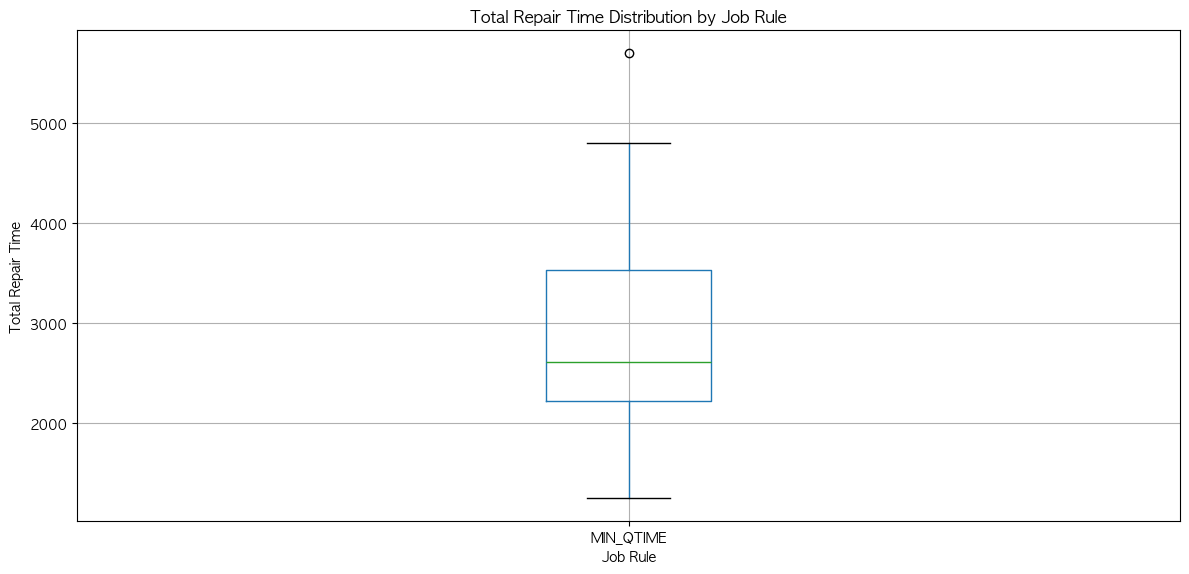

In [12]:
# ============================================================
# === PM & Repair 메트릭 비교 ===
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PM Count 분포
pm_compare_results.boxplot(column='pm_count', by=['pm_rule', 'job_rule'], ax=axes[0, 0])
axes[0, 0].set_title('PM Count Distribution')
axes[0, 0].set_xlabel('(PM Rule, Job Rule)')
axes[0, 0].set_ylabel('PM Count')
axes[0, 0].get_figure().suptitle('')

# Repair Count 분포
pm_compare_results.boxplot(column='repair_count', by=['pm_rule', 'job_rule'], ax=axes[0, 1])
axes[0, 1].set_title('Repair Count Distribution')
axes[0, 1].set_xlabel('(PM Rule, Job Rule)')
axes[0, 1].set_ylabel('Repair Count')
axes[0, 1].get_figure().suptitle('')

# Total PM Time
pm_compare_results.boxplot(column='total_pm_time', by=['pm_rule', 'job_rule'], ax=axes[1, 0])
axes[1, 0].set_title('Total PM Time Distribution')
axes[1, 0].set_xlabel('(PM Rule, Job Rule)')
axes[1, 0].set_ylabel('Total PM Time')
axes[1, 0].get_figure().suptitle('')

# Total Repair Time
pm_compare_results.boxplot(column='total_repair_time', by=['pm_rule', 'job_rule'], ax=axes[1, 1])
axes[1, 1].set_title('Total Repair Time Distribution')
axes[1, 1].set_xlabel('(PM Rule, Job Rule)')
axes[1, 1].set_ylabel('Total Repair Time')
axes[1, 1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== PM & Repair Statistics ===\n")
print(pm_compare_results.groupby(['pm_rule', 'job_rule']).agg({
    'pm_count': ['mean', 'std'],
    'repair_count': ['mean', 'std'],
    'total_pm_time': ['mean', 'std'],
    'total_repair_time': ['mean', 'std'],
}).round(2))

## Block 12. Total Score 비교 (Makespan + Q-time Violation)

=== Total Score Summary (QTIME_WEIGHT=1.0) ===


,job_rule,avg_total_score,std_total_score,avg_makespan,avg_qtime_violation
0,MIN_QTIME,10056.600081,425.762256,9627.618274,428.981807


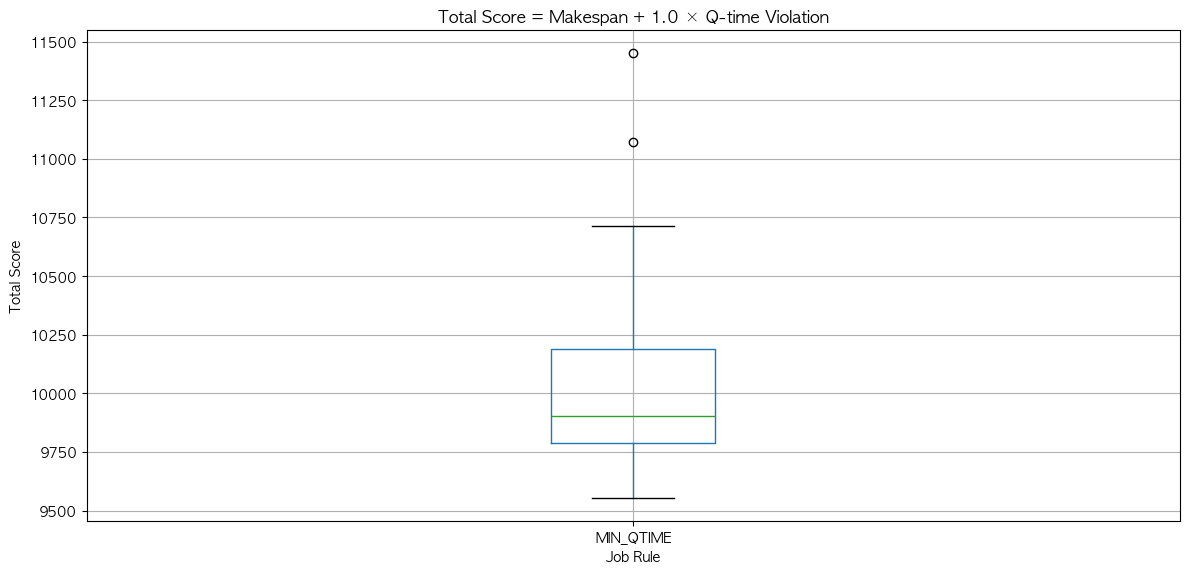


=== 최고 성능 Job Rule ===
Best Job Rule: MIN_QTIME
Avg Total Score: 10056.60
Avg Makespan: 9627.62
Avg Q-time Violation: 428.98


In [13]:
# ============================================================
# === 통합 성과 지표: Makespan + Q-time Violation ===
# ============================================================

# Total score 계산 (가중 합)
pm_compare_results['total_score'] = (
    pm_compare_results['makespan'] + 
    QTIME_WEIGHT * pm_compare_results['qtime_violation']
)

# PM Rule별 총 스코어 비교
print(f"\n=== Total Score (Makespan + {QTIME_WEIGHT}×Q-time Violation) ===\n")

score_summary = pm_compare_results.groupby('pm_rule').agg({
    'makespan': 'mean',
    'qtime_violation': 'mean',
    'total_score': ['mean', 'std'],
}).round(2)
print(score_summary)

# PM Rule + Job Rule 조합별
print(f"\n=== Total Score by PM Rule & Job Rule ===\n")
combined_score = pm_compare_results.groupby(['pm_rule', 'job_rule']).agg({
    'makespan': 'mean',
    'qtime_violation': 'mean',
    'total_score': 'mean',
}).round(2)
print(combined_score)

# 시각화: Total Score 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot by PM Rule
pm_compare_results.boxplot(column='total_score', by='pm_rule', ax=axes[0])
axes[0].set_title(f'Total Score Distribution by PM Rule (QTIME_WEIGHT={QTIME_WEIGHT})')
axes[0].set_xlabel('PM Rule')
axes[0].set_ylabel('Total Score')
axes[0].get_figure().suptitle('')

# Box plot by PM Rule + Job Rule
pm_compare_results.boxplot(column='total_score', by=['pm_rule', 'job_rule'], ax=axes[1])
axes[1].set_title('Total Score Distribution by PM Rule and Job Rule')
axes[1].set_xlabel('(PM Rule, Job Rule)')
axes[1].set_ylabel('Total Score')
axes[1].get_figure().suptitle('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Best configuration (최소 total score)
best_config = pm_compare_results.loc[pm_compare_results['total_score'].idxmin()]
print(f"\n=== Best Configuration (Minimum Total Score) ===")
print(f"PM Rule: {best_config['pm_rule']}")
print(f"Job Rule: {best_config['job_rule']}")
print(f"Total Score: {best_config['total_score']:.2f}")
print(f"Makespan: {best_config['makespan']:.2f}")
print(f"Q-time Violations: {best_config['qtime_violation']:.0f}")